Hämtar pandas för att läsa, hantera och analysera dataset. 
Hämtar matplotlib för att skapa grafer och visualiseringar. 

In [176]:
import pandas as pd # hämta pandas bibliotek för att hantera data
import matplotlib.pyplot as plt 


In [177]:
df_db = pd.read_csv("../data/processed/movies.csv")
df_db.columns

Index(['movie_id', 'title', 'release_date', 'rating', 'popularity',
       'genre_ids', 'genres', 'category', 'release_year'],
      dtype='str')

In [178]:

df_db = pd.read_csv("../data/processed/movies.csv")

print(df_db.columns)
print("genres finns:", "genres" in df_db.columns)

Index(['movie_id', 'title', 'release_date', 'rating', 'popularity',
       'genre_ids', 'genres', 'category', 'release_year'],
      dtype='str')
genres finns: True


In [179]:
df_db["genres"].head(5)

0         Animation, Family, Fantasy
1              Fantasy, Drama, Crime
2         Adventure, Fantasy, Action
3         Adventure, Fantasy, Action
4    Comedy, Drama, Fantasy, Romance
Name: genres, dtype: str

In [180]:
# hämtar data via ETL-pipeline 
import sys
sys.path.append('/Users/ghaliaghazal/Documents/Grupp7_Datavisualisering_DE_UX')


from src.etl.extract import Extract

extractor = Extract()
data = extractor.fetch_movies()

len(data) # kontrollerar antal filmer
data[0]

Fetching pages: 25/25 | Movies: 500 | Time: 7.4s


{'adult': False,
 'backdrop_path': '/zMwhWailP1WY7sb6AoE6b8ugoy.jpg',
 'genre_ids': [12, 16, 10751, 14],
 'id': 1007757,
 'title': 'Swapped',
 'original_language': 'en',
 'original_title': 'Swapped',
 'overview': 'A small woodland creature and a majestic bird, two natural sworn enemies of the Valley, magically trade places and set off on an adventure of a lifetime to switch back. Their journey soon uncovers a greater threat—one that could endanger not only their species, but the entire valley they call home.',
 'popularity': 160.2735,
 'poster_path': '/tHhxWxge06goXU6ZQH1hj7vK8Hd.jpg',
 'release_date': '2026-05-01',
 'softcore': False,
 'video': False,
 'vote_average': 8.966,
 'vote_count': 1764}

In [181]:
len(data)

500

In [182]:
# konverterar API-data till DataFrame och visar de första raderna för kontroll
df_api = pd.DataFrame(data) 
df_api.head() 

,adult,backdrop_path,genre_ids,id,title,original_language,original_title,overview,popularity,poster_path,release_date,softcore,video,vote_average,vote_count
0,False,/zMwhWailP1WY7sb6AoE6b8ugoy.jpg,"[12, 16, 10751, 14]",1007757,Swapped,en,Swapped,"A small woodland creature and a majestic bird,...",160.2735,/tHhxWxge06goXU6ZQH1hj7vK8Hd.jpg,2026-05-01,False,False,8.966,1764
1,False,/dyJvKsNs2KP8qQnAXbRwDjblViy.jpg,"[16, 10751, 14]",129,Spirited Away,ja,千と千尋の神隠し,"A young girl, Chihiro, becomes trapped in a st...",30.3779,/39wmItIWsg5sZMyRUHLkWBcuVCM.jpg,2001-07-20,False,False,8.534,18441
2,False,/b6HWTOxn1xevvyHU2K9ICvaRU6g.jpg,"[14, 18, 80]",497,The Green Mile,en,The Green Mile,A supernatural tale set on death row in a Sout...,24.6700,/8VG8fDNiy50H4FedGwdSVUPoaJe.jpg,1999-12-10,False,False,8.507,19350
3,False,/2u7zbn8EudG6kLlBzUYqP8RyFU4.jpg,"[12, 14, 28]",122,The Lord of the Rings: The Return of the King,en,The Lord of the Rings: The Return of the King,As armies mass for a final battle that will de...,36.2571,/rCzpDGLbOoPwLjy3OAm5NUPOTrC.jpg,2003-12-17,False,False,8.500,26679
4,False,/oiwc338EoBgS4sEI2ixAny4KQKg.jpg,"[12, 14, 28]",120,The Lord of the Rings: The Fellowship of the Ring,en,The Lord of the Rings: The Fellowship of the Ring,"Young hobbit Frodo Baggins, after inheriting a...",34.6489,/6oom5QYQ2yQTMJIbnvbkBL9cHo6.jpg,2001-12-18,False,False,8.436,27702


# Connect and query
ansluter till DuckDB-databasen och hämtar alla filmer som en DataFrame

In [183]:
import duckdb
# anslut till databasen
con = duckdb.connect('/Users/ghaliaghazal/Documents/Grupp7_Datavisualisering_DE_UX/data/db/movies.duckdb')
# hämta alla filmer som en tabell
df_db = con.execute("SELECT * FROM movies").df()
df_db.head()

,movie_id,title,release_date,rating,popularity,release_year
0,83533,Avatar: Fire and Ash,2025-12-17,7.373,485.097198,2025
1,1226863,The Super Mario Galaxy Movie,2026-04-01,6.953,317.093903,2026
2,502356,The Super Mario Bros. Movie,2023-04-05,7.587,225.702698,2023
3,1311031,Demon Slayer: Kimetsu no Yaiba Infinity Castle,2025-07-18,7.670,120.484398,2025
4,1159831,The Bride!,2026-03-04,6.300,91.137100,2026


## Utforska datan

In [184]:
df_db.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   movie_id      200 non-null    int32         
 1   title         200 non-null    str           
 2   release_date  200 non-null    datetime64[us]
 3   rating        200 non-null    float32       
 4   popularity    200 non-null    float32       
 5   release_year  200 non-null    int32         
dtypes: datetime64[us](1), float32(2), int32(2), str(1)
memory usage: 6.4 KB


In [185]:
df_db.describe()

,movie_id,release_date,rating,popularity,release_year
count,2.000000e+02,200,200.000000,200.000000,200.00000
mean,4.765350e+05,2014-01-31 07:55:12,7.130065,32.751999,2013.49000
min,2.200000e+01,1939-08-15 00:00:00,0.000000,7.884100,1939.00000
25%,2.012750e+03,2005-11-16 00:00:00,6.799750,13.302875,2005.00000
50%,2.886095e+05,2017-05-30 00:00:00,7.369500,16.726250,2017.00000
75%,9.832312e+05,2025-06-06 00:00:00,7.856250,23.900275,2025.00000
max,1.575337e+06,2026-11-08 00:00:00,8.534000,663.593689,2026.00000
std,5.226648e+05,NaN,1.377572,69.740295,14.47333


In [186]:
df_db.describe().round(2)

,movie_id,release_date,rating,popularity,release_year
count,200.00,200,200.00,200.00,200.00
mean,476535.01,2014-01-31 07:55:12,7.13,32.75,2013.49
min,22.00,1939-08-15 00:00:00,0.00,7.88,1939.00
25%,2012.75,2005-11-16 00:00:00,6.80,13.30,2005.00
50%,288609.50,2017-05-30 00:00:00,7.37,16.73,2017.00
75%,983231.25,2025-06-06 00:00:00,7.86,23.90,2025.00
max,1575337.00,2026-11-08 00:00:00,8.53,663.59,2026.00
std,522664.77,NaN,1.38,69.74,14.47


In [187]:
df_db.isnull() # visa om det finns några tomma värden i varje kolumn 

,movie_id,title,release_date,rating,popularity,release_year
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
195,False,False,False,False,False,False
196,False,False,False,False,False,False
197,False,False,False,False,False,False
198,False,False,False,False,False,False


In [188]:
df_db.isnull() .sum()

movie_id        0
title           0
release_date    0
rating          0
popularity      0
release_year    0
dtype: int64

## Analysera datan

In [189]:
# sorterar filmer efter betyg 
df_db.sort_values('rating', ascending=False).head(10) 

,movie_id,title,release_date,rating,popularity,release_year
114,129,Spirited Away,2001-07-20,8.534,29.763700,2001
16,129,Spirited Away,2001-07-20,8.533,38.416100,2001
25,497,The Green Mile,1999-12-10,8.505,28.282101,1999
122,497,The Green Mile,1999-12-10,8.505,22.583799,1999
68,1144107,The Legend of Hei 2,2025-07-18,8.500,13.672700,2025
154,1575337,Cosmic Princess Kaguya!,2026-01-22,8.500,13.456100,2026
169,1144107,The Legend of Hei 2,2025-07-18,8.500,11.205900,2025
22,122,The Lord of the Rings: The Return of the King,2003-12-17,8.496,27.986700,2003
118,122,The Lord of the Rings: The Return of the King,2003-12-17,8.496,25.522800,2003
31,1575337,Cosmic Princess Kaguya!,2026-01-22,8.438,21.922701,2026


In [214]:
# visar de mest populära filmerna
df_db.sort_values('popularity', ascending=False).head(10)

,movie_id,title,release_date,rating,popularity,genre_ids,genres,category,release_year
482,1226863,The Super Mario Galaxy Movie,2026-04-01,6.8,828.4621,"[10751, 35, 12, 14, 16]","Family, Comedy, Adventure, Fantasy, Animation",Fairy Tale,2026.0
205,83533,Avatar: Fire and Ash,2025-12-17,7.4,329.6580,"[878, 12, 14]","Sci-Fi, Adventure, Fantasy",Fantasy Epic,2025.0
131,502356,The Super Mario Bros. Movie,2023-04-05,7.6,171.9317,"[10751, 35, 12, 14, 16]","Family, Comedy, Adventure, Fantasy, Animation",Fairy Tale,2023.0
106,1311031,Demon Slayer: Kimetsu no Yaiba Infinity Castle,2025-07-18,7.7,137.2521,"[16, 28, 14]","Animation, Action, Fantasy",Sword and Sorcery,2025.0
41,803796,KPop Demon Hunters,2025-06-20,8.0,43.8176,"[14, 10402, 35, 16]","Fantasy, Comedy, Animation",Fantasy Epic,2025.0
345,1246049,Dracula,2025-07-30,7.1,41.4724,"[27, 14, 10749]","Horror, Fantasy, Romance",Dark Fantasy,2025.0
776,50619,The Twilight Saga: Breaking Dawn - Part 1,2011-11-16,6.2,37.2493,"[12, 14, 10749]","Adventure, Fantasy, Romance",Fantasy Epic,2011.0
3,120,The Lord of the Rings: The Fellowship of the Ring,2001-12-18,8.4,33.9804,"[12, 14, 28]","Adventure, Fantasy, Action",Sword and Sorcery,2001.0
55,14836,Coraline,2009-02-05,7.9,33.7858,"[16, 10751, 14]","Animation, Family, Fantasy",Fairy Tale,2009.0
2,122,The Lord of the Rings: The Return of the King,2003-12-17,8.5,33.4367,"[12, 14, 28]","Adventure, Fantasy, Action",Sword and Sorcery,2003.0


## Visualisera 

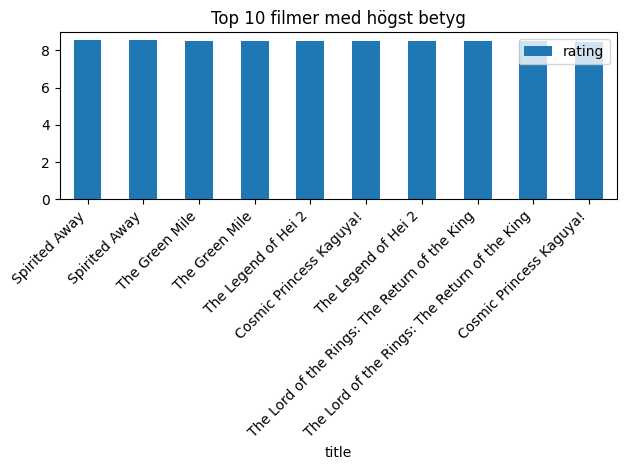

In [193]:
# # visar topp 10 filmer med högst rating
df_db.sort_values('rating', ascending=False).head(10).plot(
    x='title',
    y='rating',
    kind='bar'
)

plt.title('Top 10 filmer med högst betyg')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

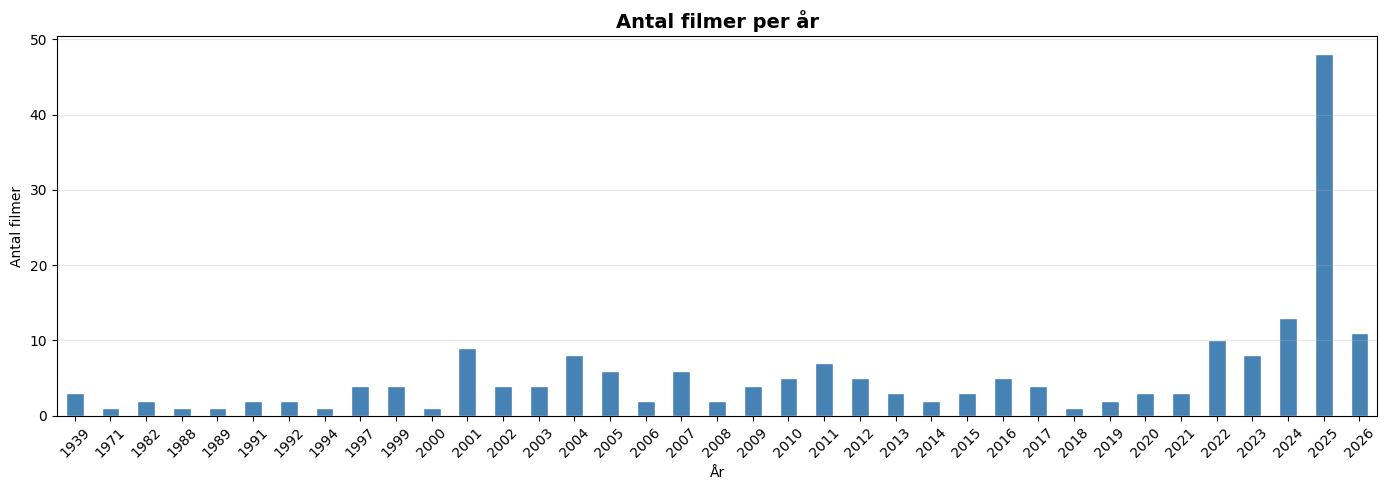

In [195]:
plt.figure(figsize=(14, 5))

df_db['release_year'].value_counts().sort_index().plot(
    kind='bar',
    color='steelblue',
    edgecolor='white'
)

plt.title('Antal filmer per år', fontsize=14, fontweight='bold')
plt.xlabel('År')
plt.ylabel('Antal filmer')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

- Power BI

In [196]:
# sparar data som CSV för eventuell användning i Power BI eller annan visualisering
df_db.to_csv('/Users/ghaliaghazal/Documents/Grupp7_Datavisualisering_DE_UX/data/processed/movies_eda.csv', index=False)

In [198]:
# laddar datasetet och kontrollerar kolumnerna
df_db = pd.read_csv("../data/processed/movies.csv")
df_db.columns

Index(['movie_id', 'title', 'release_date', 'rating', 'popularity',
       'genre_ids', 'genres', 'category', 'release_year'],
      dtype='str')

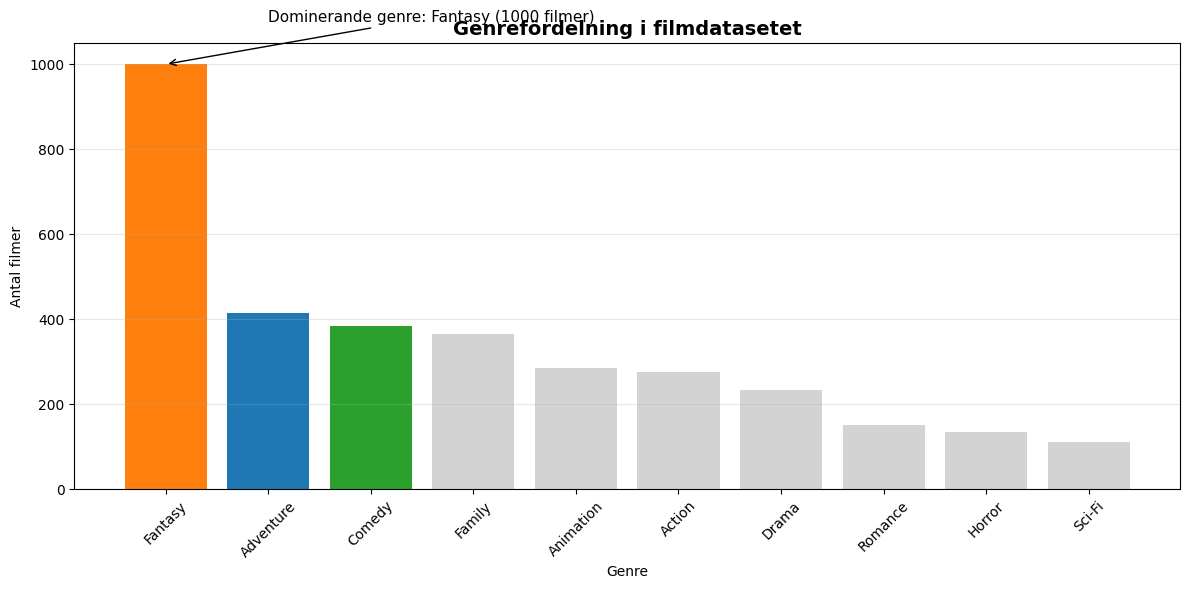

In [202]:
# visar topp 10 genrer i datasetet
from collections import Counter
import matplotlib.pyplot as plt

# dela upp genres korrekt
all_genres = df_db["genres"].dropna().str.split(", ")

# platta ut listan
flat_genres = [genre for sublist in all_genres for genre in sublist]

# räkna förekomst
genre_counts = Counter(flat_genres)

# top 10
top_genres = genre_counts.most_common(10)

labels = [g[0] for g in top_genres]
values = [g[1] for g in top_genres]

plt.figure(figsize=(12,6))

# highlight top 3
colors = ["tab:orange", "tab:blue", "tab:green"] + ["lightgray"] * (len(labels) - 3)

plt.bar(labels, values, color=colors)

# annotation på top 1
plt.annotate(
    f"Dominerande genre: {labels[0]} ({values[0]} filmer)",
    xy=(0, values[0]),
    xytext=(1, values[0] + max(values)*0.1),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=11
)

plt.title("Genrefördelning i filmdatasetet", fontsize=14, fontweight="bold")
plt.xlabel("Genre")
plt.ylabel("Antal filmer")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

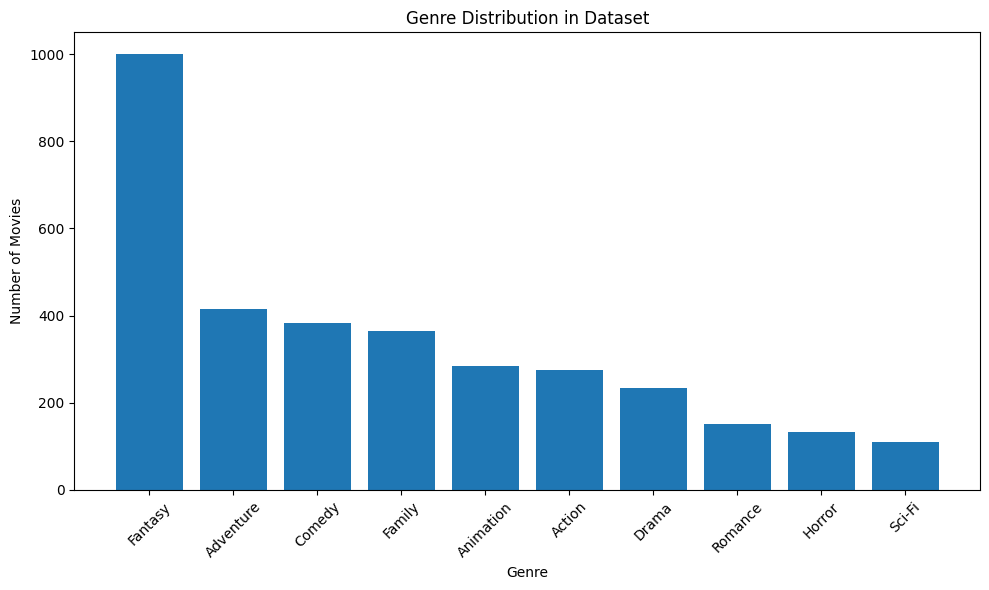

In [216]:
# visar genre-fördelning
from collections import Counter
import matplotlib.pyplot as plt

all_genres = df_db["genres"].dropna().str.split(", ")

flat_genres = [g for sublist in all_genres for g in sublist]

genre_counts = Counter(flat_genres)

top_genres = genre_counts.most_common(10)
labels = [g[0] for g in top_genres]
values = [g[1] for g in top_genres]
plt.figure(figsize=(10,6))
plt.bar(labels, values)
plt.title("Genre Distribution in Dataset")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Storytelling
Jag började med att skapa en storytelling visualisering för att visa hur filmproduktionen har utvecklats över tid.

In [207]:
# räkna hur många filmer som finns per år
movies_per_year = (
    df_db.groupby("release_year")
         .size()
         .sort_index()
)

# visa de första åren
print("Första år:")
print(movies_per_year.head())

# visa de senaste åren
print("\nSenaste år:")
print(movies_per_year.tail())

Första år:
release_year
1922.0    1
1932.0    2
1933.0    1
1938.0    1
1939.0    1
dtype: int64

Senaste år:
release_year
2022.0    40
2023.0    32
2024.0    23
2025.0    18
2026.0     1
dtype: int64


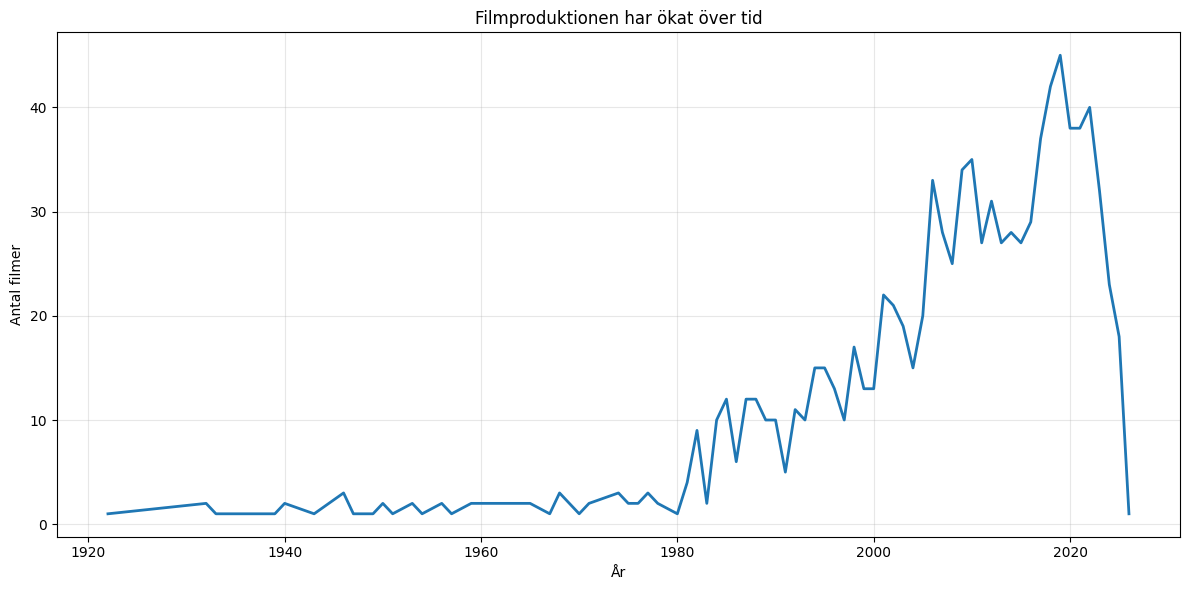

In [209]:
# skapa figur
fig, ax = plt.subplots(figsize=(12, 6))

# linjediagram över antal filmer per år
ax.plot(
    movies_per_year.index,
    movies_per_year.values,
    linewidth=2
)

ax.set_title("Filmproduktionen har ökat över tid")
ax.set_xlabel("År")
ax.set_ylabel("Antal filmer")
ax.grid(alpha=0.3) # rutnät
plt.tight_layout()
plt.show()

In [210]:
# hitta året med flest filmer
peak_year = movies_per_year.idxmax()
peak_value = movies_per_year.max()

print("Peak year:", peak_year)
print("Antal filmer:", peak_value)

Peak year: 2019.0
Antal filmer: 45


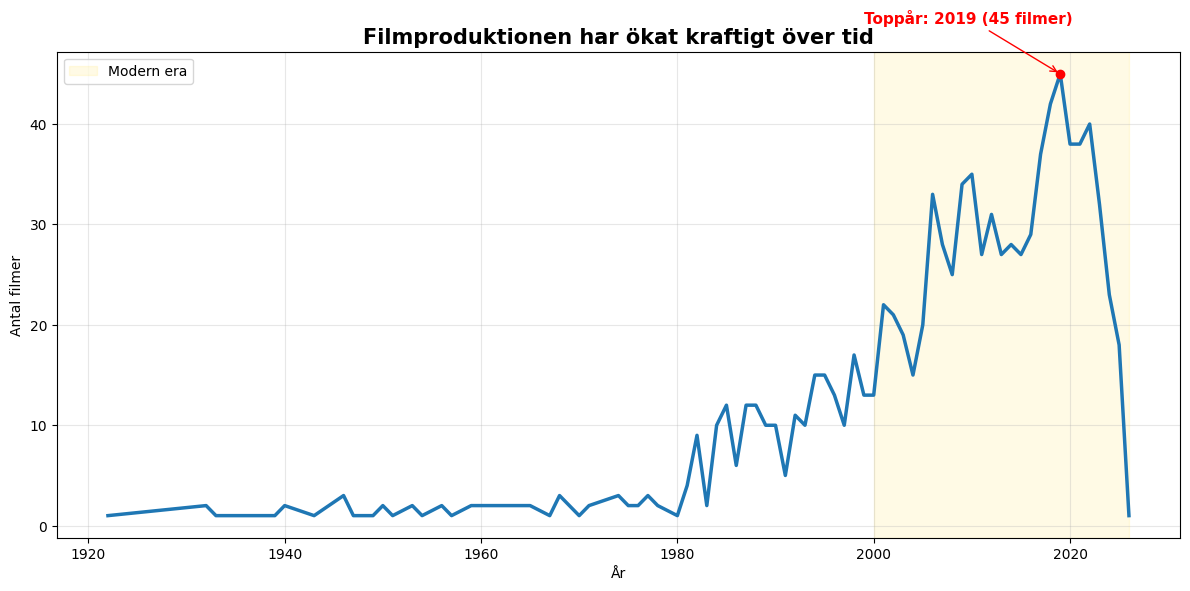

In [218]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    movies_per_year.index,
    movies_per_year.values,
    linewidth=2.5
)
ax.set_title("Filmproduktionen har ökat kraftigt över tid", fontsize=15, fontweight="bold")

ax.set_xlabel("År")
ax.set_ylabel("Antal filmer")
ax.grid(alpha=0.3)

ax.axvspan(2000, movies_per_year.index.max(), alpha=0.1, color="gold", label="Modern era")

peak_year = movies_per_year.idxmax()
peak_value = movies_per_year.max()

ax.scatter(peak_year, peak_value, color="red", zorder=5)

ax.annotate(
    f"Toppår: {int(peak_year)} ({peak_value} filmer)",
    xy=(peak_year, peak_value),
    xytext=(peak_year - 20, peak_value + 5),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=11,
    color="red",
    fontweight="bold"
)

plt.tight_layout()
plt.legend()
plt.savefig("storytelling_movie_production_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

Filmproduktionen i datasetet har ökat kraftigt över tid, med en tydlig topp runt 2019. Detta visar att majoriteten av filmerna i datasetet är relativt nya, vilket tyder på en stark ökning i filmproduktion under moderna år.